# Shared model setup: splits + metrics

One shared definition of train/test split, CV folds, and evaluation
metrics, so 3 different models (built separately) stay comparable.

Each person then builds their own model in the "Your model here" section,
using the same `cv_folds`, `train_df` / `test_df`, and `regression_metrics`.


## 1. Load data

In [32]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import ParameterGrid
from sklearn.neural_network import MLPRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
import gc
import optuna
import time
import joblib
from sklearn.base import BaseEstimator, TransformerMixin
import matplotlib.pyplot as plt

In [3]:
DATA_PATH = Path.cwd().parent / "data" / "model_input" / "df_model_input.csv"

df = pd.read_csv(DATA_PATH).reset_index(drop=True)
print(df.shape)

YEAR_COL = "closdate_year"          
TARGET   = "ncliGrowthNextYear"  
ID_COL = "idnr"

(1745282, 80)


In [4]:
df.head(5)

,report_date,lm_positive,lm_negative,lm_polarity,uncertainty_ratio,litigious_ratio,constraining_ratio,strong_modal_ratio,weak_modal_ratio,ifo_business_climate,...,log_toas,log_empl,ncliGrowthThisYear,toas_growth,cash_growth,growth_volatility,firm_age,years_in_panel,naics_2digit,is_na_empl
0,2013-12-01,420,652,-0.216418,0.016592,0.018863,0.011103,0.001009,0.004038,100.4,...,7.595447,0.000000,NaN,NaN,NaN,NaN,36.0,0,31,1
1,2014-12-01,265,402,-0.205397,0.020557,0.014647,0.003769,0.001970,0.006167,98.2,...,7.592642,0.000000,-0.034155,-0.002801,0.127094,NaN,37.0,1,31,1
2,2016-12-01,352,677,-0.315841,0.021990,0.012566,0.005463,0.002117,0.005600,101.0,...,7.514275,5.003946,-0.832512,-0.075375,-0.493523,0.564524,39.0,2,31,0
3,2017-12-01,397,547,-0.158898,0.016656,0.015763,0.006186,0.002141,0.004342,104.7,...,7.512180,4.718499,-0.093514,-0.002093,-0.112008,0.444788,40.0,3,31,0
4,2018-12-01,359,513,-0.176606,0.020424,0.012030,0.006295,0.002518,0.004337,101.2,...,7.472122,4.795791,-0.119000,-0.039266,-0.331663,0.419497,41.0,4,31,0


### Count missing value

In [5]:
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)

summary = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
}).sort_values("missing_pct", ascending=False)

summary[missing_pct > 0]

/tmp/ipykernel_7496/2135668921.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  summary[missing_pct > 0]


,missing_count,missing_pct
wkca,680658,39.00
working_capital_ratio,680658,39.00
empl,675543,38.71
cred,665458,38.13
gearing,662930,37.98
loan,658999,37.76
growth_volatility,549276,31.47
ocli,512417,29.36
quick_ratio,512168,29.35
current_ratio,494482,28.33


### Check outlier

In [6]:
def outlier_report(df, cols, lower_pct=0.01, upper_pct=0.99):
    """Summarize outlier exposure per column using train-only percentiles."""
    rows = []
    for col in cols:
        s = df[col].dropna()
        if len(s) == 0:
            continue
        lo, hi = s.quantile([lower_pct, upper_pct])
        n_low = (s < lo).sum()
        n_high = (s > hi).sum()
        rows.append({
            "column": col,
            "skew": s.skew(),
            "min": s.min(),
            "p1": lo,
            "p50": s.median(),
            "p99": hi,
            "max": s.max(),
            "n_below_p1": n_low,
            "n_above_p99": n_high,
            "pct_flagged": (n_low + n_high) / len(s) * 100,
        })
    return pd.DataFrame(rows).sort_values("pct_flagged", ascending=False)

numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(
    ["ncliGrowthNextYear"]  # exclude target
)
report = outlier_report(df, numeric_cols)
report[report["pct_flagged"] > 0].round(3)

/home/huyn/MLforEcon/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4608: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a
/home/huyn/MLforEcon/.venv/lib/python3.12/site-packages/pandas/core/nanops.py:1275: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean
/home/huyn/MLforEcon/.venv/lib/python3.12/site-packages/pandas/core/nanops.py:1275: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


,column,skew,min,p1,p50,p99,max,n_below_p1,n_above_p99,pct_flagged
69,growth_volatility,0.752,0.000000e+00,0.004,0.279,9.320000e-01,1.413000e+00,11961,11961,2.000
54,wkca,352.379,-1.110000e+12,-897997.290,165.743,2.571511e+07,1.007681e+13,10647,10647,2.000
63,working_capital_ratio,1.245,-1.180000e-01,-0.118,0.069,8.530000e-01,8.530000e-01,10647,10647,2.000
59,quick_ratio,7.326,4.800000e-02,0.048,1.842,1.485751e+03,1.485753e+03,12332,12332,2.000
56,gearing,6.433,-2.231600e+01,-22.315,0.557,1.555510e+02,1.555620e+02,10824,10824,2.000
60,cash_ratio,1.194,0.000000e+00,0.000,0.124,8.330000e-01,8.330000e-01,16822,16822,2.000
67,toas_growth,831.605,-1.000000e+00,-0.483,0.042,3.082000e+00,1.377193e+07,14600,14600,2.000
66,ncliGrowthThisYear,-0.048,-1.000000e+00,-0.968,-0.040,9.070000e-01,1.000000e+00,14600,14600,2.000
44,osfd,607.777,-1.272615e+14,-2356765.030,450.275,5.939835e+07,2.596675e+14,17060,17060,2.000
36,cuas,654.892,-2.715840e+05,41.819,1455.170,5.829177e+07,6.666670e+14,17453,17453,2.000


### Feature engineering

In [7]:
def safe_ratio(
    numerator: pd.Series,
    denominator: pd.Series,
    *,
    require_positive_denominator: bool = True,
) -> pd.Series:
    numerator = pd.to_numeric(numerator, errors="coerce")
    denominator = pd.to_numeric(denominator, errors="coerce")
    valid = numerator.notna() & denominator.notna()
    if require_positive_denominator:
        valid &= denominator > 0
    else:
        valid &= denominator != 0
    out = pd.Series(np.nan, index=numerator.index, dtype="float32")
    out.loc[valid] = (numerator.loc[valid] / denominator.loc[valid]).astype("float32")
    return out.replace([np.inf, -np.inf], np.nan)

# Sort once so all lagged firm features use only t and earlier observations.
df = df.sort_values([ID_COL, YEAR_COL]).copy()
firm_group = df.groupby(ID_COL, sort=False)
lag_year = firm_group[YEAR_COL].shift(1)
consecutive = (df[YEAR_COL] - lag_year).eq(1)

# -----------------------------------------------------------------------------
# Ratios based on documented balance-sheet identities. No data-driven
# winsorization is used, so test-year values cannot influence training values.
# -----------------------------------------------------------------------------
if {"cuas", "culi"}.issubset(df.columns):
    df["current_ratio_clean"] = safe_ratio(df["cuas"], df["culi"])
    df["log1p_current_ratio_clean"] = np.log1p(
        df["current_ratio_clean"].clip(lower=0)
    ).astype("float32")

if {"cuas", "stok", "culi"}.issubset(df.columns):
    quick_assets = df["cuas"] - df["stok"]
    df["quick_ratio_clean"] = safe_ratio(quick_assets, df["culi"])
    df["log1p_quick_ratio_clean"] = np.log1p(
        df["quick_ratio_clean"].clip(lower=0)
    ).astype("float32")

if {"shfd", "toas"}.issubset(df.columns):
    df["solvency_ratio_clean"] = safe_ratio(df["shfd"], df["toas"])

if {"ncli", "loan", "shfd"}.issubset(df.columns):
    # Gearing is undefined or difficult to interpret with non-positive equity.
    gearing_num = df["ncli"] + df["loan"]
    df["gearing_ratio_clean"] = safe_ratio(gearing_num, df["shfd"])
    df["log1p_gearing_ratio_clean"] = np.log1p(
        df["gearing_ratio_clean"].clip(lower=0)
    ).astype("float32")

if {"ncli", "culi", "toas"}.issubset(df.columns):
    df["liabilities_to_assets"] = safe_ratio(df["ncli"] + df["culi"], df["toas"])

if {"wkca", "toas"}.issubset(df.columns):
    df["working_capital_to_assets"] = safe_ratio(
        df["wkca"], df["toas"], require_positive_denominator=True
    )

if {"stok", "cuas"}.issubset(df.columns):
    valid = (df["cuas"] > 0) & (df["stok"] >= 0) & (df["stok"] <= df["cuas"])
    df["inventory_share_current_assets"] = np.where(
        valid, df["stok"] / df["cuas"], np.nan
    ).astype("float32")

if {"debt", "cuas"}.issubset(df.columns):
    valid = (df["cuas"] > 0) & (df["debt"] >= 0) & (df["debt"] <= df["cuas"])
    df["receivables_share_current_assets"] = np.where(
        valid, df["debt"] / df["cuas"], np.nan
    ).astype("float32")

if {"cash", "toas"}.issubset(df.columns):
    valid = (df["toas"] > 0) & (df["cash"] >= 0) & (df["cash"] <= df["toas"])
    df["cash_to_assets"] = np.where(valid, df["cash"] / df["toas"], np.nan).astype("float32")

if {"fias", "toas"}.issubset(df.columns):
    valid = (df["toas"] > 0) & (df["fias"] >= 0) & (df["fias"] <= df["toas"])
    df["fixed_assets_share"] = np.where(valid, df["fias"] / df["toas"], np.nan).astype("float32")

if {"ltdb", "ncli"}.issubset(df.columns):
    valid = (df["ncli"] > 0) & (df["ltdb"] >= 0) & (df["ltdb"] <= df["ncli"])
    df["ltdb_share_of_ncli"] = np.where(valid, df["ltdb"] / df["ncli"], np.nan).astype("float32")

# -----------------------------------------------------------------------------
# Stable changes in firm levels. These replace unstable cash percentage growth
# and make the time direction explicit.
# -----------------------------------------------------------------------------
if "log_toas" not in df.columns and "toas" in df.columns:
    df["log_toas"] = np.log1p(df["toas"].clip(lower=0)).astype("float32")
if "log_empl" not in df.columns and "empl" in df.columns:
    df["log_empl"] = np.log1p(df["empl"].clip(lower=0)).astype("float32")

if "log_toas" in df.columns:
    lag_log_toas = firm_group["log_toas"].shift(1)
    df["log_toas_change_clean"] = np.where(
        consecutive, df["log_toas"] - lag_log_toas, np.nan
    ).astype("float32")

if {"cash", "toas"}.issubset(df.columns):
    lag_cash = firm_group["cash"].shift(1)
    lag_toas = firm_group["toas"].shift(1)
    valid = consecutive & lag_toas.gt(0)
    df["cash_change_to_lagged_assets"] = np.where(
        valid, (df["cash"] - lag_cash) / lag_toas, np.nan
    ).astype("float32")

if "ncliGrowthThisYear" in df.columns:
    rolling_volatility = (
        df.groupby(ID_COL, sort=False)["ncliGrowthThisYear"]
          .rolling(window=3, min_periods=2)
          .std()
          .reset_index(level=0, drop=True)
    )
    df["ncli_growth_volatility_3y"] = rolling_volatility.astype("float32")

# -----------------------------------------------------------------------------
# Macro transformations.
# Confidence balances can cross zero, so use first differences.
# Positive indices use percentage changes calculated from annual levels.
# -----------------------------------------------------------------------------
BALANCE_LEVELS = [
    "de_construction_confidence",
    "de_consumer_confidence",
    "de_industry_confidence",
    "de_retail_confidence",
    "de_services_confidence",
]
POSITIVE_INDEX_LEVELS = [
    "de_economic_sentiment_index",
    "de_employment_expectations_index",
    "ifo_business_climate",
    "ifo_business_expectations",
    "ifo_business_situation",
]

available_macro_levels = [
    c for c in BALANCE_LEVELS + POSITIVE_INDEX_LEVELS if c in df.columns
]
if available_macro_levels:
    annual_macro = (
        df.groupby(YEAR_COL, sort=True)[available_macro_levels]
          .median(numeric_only=True)
          .sort_index()
    )

    for col in [c for c in BALANCE_LEVELS if c in annual_macro.columns]:
        new_col = f"{col}_change_clean"
        year_values = annual_macro[col].diff()
        df[new_col] = df[YEAR_COL].map(year_values).astype("float32")

    for col in [c for c in POSITIVE_INDEX_LEVELS if c in annual_macro.columns]:
        new_col = f"{col}_pct_change_clean"
        current = annual_macro[col]
        previous = current.shift(1)
        year_values = ((current / previous) - 1).where((current > 0) & (previous > 0))
        df[new_col] = df[YEAR_COL].map(year_values).astype("float32")

# -----------------------------------------------------------------------------
# Text counts are used only if a document-length variable exists. Otherwise,
# raw lm_positive/lm_negative counts are omitted and polarity/ratios are used.
# -----------------------------------------------------------------------------
TOKEN_COUNT_CANDIDATES = [
    "token_count", "n_tokens", "word_count", "total_words", "document_length"
]
token_count_col = next((c for c in TOKEN_COUNT_CANDIDATES if c in df.columns), None)
if token_count_col is not None:
    for source, target in [
        ("lm_positive", "lm_positive_frequency"),
        ("lm_negative", "lm_negative_frequency"),
    ]:
        if source in df.columns:
            df[target] = safe_ratio(df[source], df[token_count_col])
    print(f"Normalized sentiment counts using: {token_count_col}")
else:
    print("No document-length column found: raw positive/negative counts will be omitted.")

# Replace any remaining infinities and downcast new floating-point columns.
float64_cols = df.select_dtypes(include="float64").columns
df[float64_cols] = df[float64_cols].astype("float32")
df.replace([np.inf, -np.inf], np.nan, inplace=True)

del firm_group, lag_year, consecutive
gc.collect()


No document-length column found: raw positive/negative counts will be omitted.


20

## 2. Config


In [8]:
MIN_TRAIN_YEARS = 5     # first fold: train on this many years, test on the next
TEST_YEARS = [2020, 2021, 2022]

class QuantileWinsorizer(BaseEstimator, TransformerMixin):
    """Clip numeric features using quantiles learned on the training data only."""

    def __init__(self, lower_quantile: float = 0.01, upper_quantile: float = 0.99):
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile

    @staticmethod
    def _as_array(X) -> np.ndarray:
        if hasattr(X, "to_numpy"):
            return X.to_numpy(dtype=np.float32, copy=True)
        return np.asarray(X, dtype=np.float32)

    def fit(self, X, y=None):
        values = self._as_array(X)
        self.n_features_in_ = values.shape[1]
        if hasattr(X, "columns"):
            self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            lower = np.nanquantile(values, self.lower_quantile, axis=0)
            upper = np.nanquantile(values, self.upper_quantile, axis=0)
        self.lower_bounds_ = np.where(np.isfinite(lower), lower, -np.inf).astype(np.float32)
        self.upper_bounds_ = np.where(np.isfinite(upper), upper, np.inf).astype(np.float32)
        return self

    def transform(self, X):
        return np.clip(self._as_array(X), self.lower_bounds_, self.upper_bounds_)

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return np.asarray(input_features, dtype=object)
        if hasattr(self, "feature_names_in_"):
            return self.feature_names_in_
        return np.asarray([f"x{i}" for i in range(self.n_features_in_)], dtype=object)

In [9]:
def present(columns: list[str]) -> list[str]:
    return [c for c in columns if c in df.columns]

CATEGORY_COLS = present(["naics_2digit", "type"])

FIRM_NUMERIC_CANDIDATES = [
    "log_toas",
    "log_empl",                 # raw empl is intentionally omitted
    "firm_age",
    "years_in_panel",
    "is_na_empl",
    "ncliGrowthThisYear",
    "log_toas_change_clean",
    "cash_change_to_lagged_assets",
    "ncli_growth_volatility_3y",
    "log1p_current_ratio_clean",
    "log1p_quick_ratio_clean",
    "solvency_ratio_clean",
    "log1p_gearing_ratio_clean",
    "liabilities_to_assets",
    "working_capital_to_assets",
    "inventory_share_current_assets",
    "receivables_share_current_assets",
    "cash_to_assets",
    "fixed_assets_share",
    "ltdb_share_of_ncli",
]
FIRM_FEATURES = present(FIRM_NUMERIC_CANDIDATES) + CATEGORY_COLS

SURVEY_LEVEL_FEATURES = present(BALANCE_LEVELS + POSITIVE_INDEX_LEVELS)
SURVEY_CHANGE_FEATURES = present(
    [f"{c}_change_clean" for c in BALANCE_LEVELS]
    + [f"{c}_pct_change_clean" for c in POSITIVE_INDEX_LEVELS]
)
SURVEY_FEATURES = SURVEY_LEVEL_FEATURES + SURVEY_CHANGE_FEATURES

TEXT_FEATURES = present([
    "lm_polarity",
    "uncertainty_ratio",
    "litigious_ratio",
    "constraining_ratio",
    "strong_modal_ratio",
    "weak_modal_ratio",
    "lm_positive_frequency",
    "lm_negative_frequency",
])

FEATURE_SETS = {
    "firm": FIRM_FEATURES,
    "firm_survey": list(dict.fromkeys(FIRM_FEATURES + SURVEY_FEATURES)),
    "firm_survey_text": list(dict.fromkeys(FIRM_FEATURES + SURVEY_FEATURES + TEXT_FEATURES)),
}

for name, cols in FEATURE_SETS.items():
    if not cols:
        raise ValueError(f"Feature set {name!r} is empty.")
    print(f"{name:>18}: {len(cols):>3} columns")
    print(cols)

# Explicit leakage / redundancy guard.
FORBIDDEN_FEATURES = {
    TARGET, YEAR_COL, "year", ID_COL, "naics_core_code", "empl",
    "cash_growth", "toas_growth",
    "de_construction_confidence_growth", "de_consumer_confidence_growth",
    "de_industry_confidence_growth", "de_retail_confidence_growth",
    "de_services_confidence_growth",
    "lm_positive", "lm_negative",
}
for set_name, cols in FEATURE_SETS.items():
    overlap = sorted(set(cols).intersection(FORBIDDEN_FEATURES))
    if overlap:
        raise AssertionError(f"Forbidden features in {set_name}: {overlap}")


              firm:  22 columns
['log_toas', 'log_empl', 'firm_age', 'years_in_panel', 'is_na_empl', 'ncliGrowthThisYear', 'log_toas_change_clean', 'cash_change_to_lagged_assets', 'ncli_growth_volatility_3y', 'log1p_current_ratio_clean', 'log1p_quick_ratio_clean', 'solvency_ratio_clean', 'log1p_gearing_ratio_clean', 'liabilities_to_assets', 'working_capital_to_assets', 'inventory_share_current_assets', 'receivables_share_current_assets', 'cash_to_assets', 'fixed_assets_share', 'ltdb_share_of_ncli', 'naics_2digit', 'type']
       firm_survey:  42 columns
['log_toas', 'log_empl', 'firm_age', 'years_in_panel', 'is_na_empl', 'ncliGrowthThisYear', 'log_toas_change_clean', 'cash_change_to_lagged_assets', 'ncli_growth_volatility_3y', 'log1p_current_ratio_clean', 'log1p_quick_ratio_clean', 'solvency_ratio_clean', 'log1p_gearing_ratio_clean', 'liabilities_to_assets', 'working_capital_to_assets', 'inventory_share_current_assets', 'receivables_share_current_assets', 'cash_to_assets', 'fixed_asset

Reasoning of set min_train_year = 5:
- Early years have far fewer, differently-composed firms (panel coverage
expanded over time)
- If a CV fold trains only on those sparse years, its
score reflects a coverage-composition shift, not real forecasting
difficulty.
- `MIN_TRAIN_YEARS = 5` is a starting recommendation: it dilutes the sparse
years to roughly ~15-20% of fold 1's training set 

In [10]:
year_counts = df[YEAR_COL].value_counts().sort_index()
print(year_counts)

years_sorted = sorted(year_counts.index)

# Adjust this to wherever coverage visibly stabilizes in the printout above
SPARSE_CUTOFF_YEAR = 2013

print(f"\n{'min_train_years':>16} {'first_test_year':>16} {'sparse_share':>14}")
for m in range(4, 10):
    if m >= len(years_sorted):
        continue
    train_years = years_sorted[:m]
    total = sum(year_counts[y] for y in train_years)
    sparse = sum(year_counts[y] for y in train_years if y < SPARSE_CUTOFF_YEAR)
    share = sparse / total if total else float("nan")
    first_test_year = years_sorted[m]
    print(f"{m:>16} {first_test_year:>16} {share:>13.1%}")


closdate_year
2010     13132
2011     12950
2012     21695
2013     39951
2014    138297
2015    145276
2016    149169
2017    190184
2018    201605
2019    201110
2020    219759
2021    225653
2022    184816
2023      1685
Name: count, dtype: int64

 min_train_years  first_test_year   sparse_share
               4             2014         54.5%
               5             2015         21.1%
               6             2016         12.9%
               7             2017          9.2%
               8             2018          6.7%
               9             2019          5.2%


Note: Reasoning about using test years from 2020, explicitly separate the COVID pandemic on the test set only, because:
- This measures "if an unprecedented shock hits, and my model has never seen anything like it, how badly does it break?" That's actually the most realistic deployment scenario - a bank planning financing programs can't guarantee the next crisis looks like something already in its training data. This is the harder, more honest test.

## 3. Fold + metric functions


In [11]:
def rolling_origin_folds(years, min_train_years=4, max_year=None):
    """Expanding-window folds: train on years[:i], test on years[i].

    Example with years 2013..2020, min_train_years=4:
        Fold 1: train <=2016, test 2017
        Fold 2: train <=2017, test 2018
        Fold 3: train <=2018, test 2019
        Fold 4: train <=2019, test 2020
    Only include years in the training set
    """
    years = sorted(set(years))
    return [
        (years[:i], years[i])
        for i in range(min_train_years, len(years))
    ]


def regression_metrics(y_true, y_pred, baseline_value):
    """RMSE, MAE, R2_oos vs. a naive baseline (e.g. train-set mean).

    R2_oos > 0 means the model beats "always predict the baseline value"
    on this data. Use the SAME baseline_value (train-set mean) for every
    model so the comparison is apples-to-apples
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    yt, yp = y_true[mask], y_pred[mask]

    if len(yt) == 0:
        return {"RMSE": np.nan, "MAE": np.nan, "R2_oos": np.nan, "n": 0}

    err = yt - yp
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    ss_res = np.sum(err ** 2)
    ss_baseline = np.sum((yt - baseline_value) ** 2)
    r2_oos = float(1 - ss_res / ss_baseline) if ss_baseline > 0 else np.nan

    return {"RMSE": rmse, "MAE": mae, "R2_oos": r2_oos, "n": int(mask.sum())}


## 4. Train/test split + CV folds

- 4.1. Train/test split:
    - Train set: 2012-2019
    - Test set: 2020-2023
    
    Test set is set aside and never touched during tuning
- 4.2. Create multiple folds for cross validation, built from train set only, so a test years can never leak into folds.


In [12]:
# Train/test split
train_df = df[~df[YEAR_COL].isin(TEST_YEARS)]
train_df = train_df[train_df[YEAR_COL] < min(TEST_YEARS)]   # drop anything before test block too, if present
test_df  = df[df[YEAR_COL].isin(TEST_YEARS)]
baseline_value = train_df[TARGET].mean()   # SAME baseline for every model

print(f"train: {train_df.shape}, test {TEST_YEARS}: {test_df.shape}")


train: (1113369, 107), test [2020, 2021, 2022]: (630228, 107)


In [13]:
years = train_df[YEAR_COL].unique()

cv_folds = rolling_origin_folds(years, min_train_years=MIN_TRAIN_YEARS)

for train_years, test_year in cv_folds:
    print(f"train <= {max(train_years)} ({len(train_years)} yrs)  ->  test {test_year}")


train <= 2014 (5 yrs)  ->  test 2015
train <= 2015 (6 yrs)  ->  test 2016
train <= 2016 (7 yrs)  ->  test 2017
train <= 2017 (8 yrs)  ->  test 2018
train <= 2018 (9 yrs)  ->  test 2019


## 5. Neural network model


In [14]:
FEATURE_SETS.keys()

dict_keys(['firm', 'firm_survey', 'firm_survey_text'])

In [15]:
import time
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

all_best_params = {}
all_studies = {}

# for feature_set_name, FEATURE_COLS in FEATURE_SETS.items():
feature_set_name = "firm_survey_text"
FEATURE_COLS = FEATURE_SETS[feature_set_name]
print(f"\n{'='*60}")
print(f"Tuning feature set: {feature_set_name}")
print(f"{'='*60}")

cat_cols = [c for c in CATEGORY_COLS if c in FEATURE_COLS]
numeric_cols = [c for c in FEATURE_COLS if c not in cat_cols]

start_time = time.time()

def objective(trial, FEATURE_COLS=FEATURE_COLS, cat_cols=cat_cols, numeric_cols=numeric_cols):
    trial_start = time.time()

    layer_choice = trial.suggest_categorical(
        "hidden_layer_sizes",
        ["64", "64_32", "128_64", "64_32_16"],
    )
    hidden_layer_sizes = tuple(map(int, layer_choice.split("_")))

    params = {
        "hidden_layer_sizes": hidden_layer_sizes,
        "learning_rate_init": trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True),
        "alpha": trial.suggest_float("alpha", 1e-5, 1e-1, log=True),
        "max_iter": 200,
    }

    fold_scores = []
    for i, (train_years, test_year) in enumerate(cv_folds):
        fold_train = train_df[train_df[YEAR_COL].isin(train_years)].copy()
        fold_test = train_df[train_df[YEAR_COL] == test_year].copy()

        fold_train = fold_train.dropna(subset=[TARGET]).copy()
        fold_test = fold_test.dropna(subset=[TARGET]).copy()

        for col in FEATURE_COLS:
            fold_train[col] = pd.to_numeric(fold_train[col], errors="coerce")
            fold_test[col] = pd.to_numeric(fold_test[col], errors="coerce")

        fold_train[FEATURE_COLS] = fold_train[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
        fold_test[FEATURE_COLS] = fold_test[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)

        preprocess = ColumnTransformer([
            ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols),
            ("num", Pipeline([
                ("winsor", QuantileWinsorizer(0.01, 0.99)),
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), numeric_cols),
        ])

        model = Pipeline([
            ("preprocess", preprocess),
            ("model", MLPRegressor(
                activation="relu", solver="adam",
                early_stopping=True, n_iter_no_change=20,
                random_state=42, **params
            )),
        ])

        model.fit(fold_train[FEATURE_COLS], fold_train[TARGET])
        preds = model.predict(fold_test[FEATURE_COLS])
        score = regression_metrics(
            fold_test[TARGET].values, preds, fold_train[TARGET].mean()
        )["RMSE"]

        fold_scores.append(score)

        trial.report(np.mean(fold_scores), step=i)
        if trial.should_prune():
            raise optuna.TrialPruned()

    elapsed_trial = time.time() - trial_start
    trial.set_user_attr("runtime_sec", round(elapsed_trial, 3))
    return np.mean(fold_scores)

study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=1)
)
study.optimize(objective, n_trials=40, n_jobs=1)

elapsed = time.time() - start_time

best_hidden = tuple(map(int, study.best_params["hidden_layer_sizes"].split("_")))
best_params = {
    "hidden_layer_sizes": best_hidden,
    "learning_rate_init": study.best_params["learning_rate_init"],
    "alpha": study.best_params["alpha"],
}

print(f"[{feature_set_name}] Best params:", best_params)
print(f"[{feature_set_name}] Best mean RMSE:", study.best_value)
print(f"[{feature_set_name}] Tuning runtime: {elapsed:.2f} seconds")
print(f"[{feature_set_name}] Per-trial runtime (sec):", [t.user_attrs.get("runtime_sec") for t in study.trials])

all_best_params[feature_set_name] = best_params
all_studies[feature_set_name] = study

print("\n\nSummary of best params per feature set:")
for name, params in all_best_params.items():
    print(f"  {name}: {params}")

[I 2026-08-08 22:57:16,802] A new study created in memory with name: no-name-9b56d6c6-aca1-48b6-b5c2-f982419fe351



Tuning feature set: firm_survey_text


[I 2026-08-08 23:03:53,449] Trial 0 finished with value: 0.39401162823868285 and parameters: {'hidden_layer_sizes': '64_32', 'learning_rate_init': 0.0005329119806162957, 'alpha': 0.0001914914194463956}. Best is trial 0 with value: 0.39401162823868285.
[I 2026-08-08 23:09:30,766] Trial 1 finished with value: 0.38574337460977504 and parameters: {'hidden_layer_sizes': '64_32_16', 'learning_rate_init': 0.0035010320740163896, 'alpha': 0.022214192340293763}. Best is trial 1 with value: 0.38574337460977504.
[I 2026-08-08 23:16:46,166] Trial 2 finished with value: 0.39469951528338576 and parameters: {'hidden_layer_sizes': '64', 'learning_rate_init': 0.0005112522144694712, 'alpha': 0.0004323569228981707}. Best is trial 1 with value: 0.38574337460977504.
[I 2026-08-08 23:21:56,492] Trial 3 finished with value: 0.3853778085675389 and parameters: {'hidden_layer_sizes': '64', 'learning_rate_init': 0.002408168821306271, 'alpha': 0.0012592153609132337}. Best is trial 3 with value: 0.3853778085675389.

[firm_survey_text] Best params: {'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.0013961091133985275, 'alpha': 7.235341702361802e-05}
[firm_survey_text] Best mean RMSE: 0.38095646634291513
[firm_survey_text] Tuning runtime: 8516.12 seconds
[firm_survey_text] Per-trial runtime (sec): [396.641, 337.313, 435.396, 310.321, 635.423, 477.333, None, None, None, None, 366.273, 296.167, 378.168, None, None, 309.692, None, None, None, None, None, 353.385, None, 398.673, 433.464, 387.657, None, None, 320.709, None, None, None, None, None, None, None, None, None, None, 799.441]


Summary of best params per feature set:
  firm_survey_text: {'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.0013961091133985275, 'alpha': 7.235341702361802e-05}


**Hyperparameter tuning methodd**: use **Optuna (Bayesian optimization)** instead of **Grid search**, because:
- **Grid search**: have the list of candidate value for each hyperparameters that need to be tuned. Model trys every combination of hyperparameters. It required equal effort for every trial and computational cost.
- **Optuna**: It models which regions of hyperparameter space look promising and spends most of its budget there, and it supports pruning: killing off a trial partway through if intermediate folds already look bad, so we don't pay full price for hopeless configs.


In [37]:
def make_final_pipeline(feature_cols, model_params):
    cat_cols = [c for c in CATEGORY_COLS if c in feature_cols]
    num_cols = [c for c in feature_cols if c not in cat_cols]

    return Pipeline([
        ("preprocess", ColumnTransformer([
            ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols),
            ("num", Pipeline([
                ("winsor", QuantileWinsorizer(0.01, 0.99)),
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), num_cols),
        ])),
        ("model", MLPRegressor(
            activation="relu",
            solver="adam",
            early_stopping=True,
            n_iter_no_change=20,
            random_state=42,
            **model_params
        )),
    ])

final_models = {}
final_metrics = {}

for key, value in FEATURE_SETS.items():
    FEATURE_COLS = value
    model_params = all_best_params['firm_survey_text']  # Use the best params from the tuned feature set

    model = make_final_pipeline(FEATURE_COLS, model_params)
    model.fit(train_df[FEATURE_COLS], train_df[TARGET])
    final_preds = model.predict(test_df[FEATURE_COLS])

    train_metrics = regression_metrics(
        train_df[TARGET].values,
        model.predict(train_df[FEATURE_COLS]),
        train_df[TARGET].mean()
    )
    test_metrics = regression_metrics(
        test_df[TARGET].values,
        final_preds,
        train_df[TARGET].mean()
    )

    final_models[key] = model
    final_metrics[key] = {"train": train_metrics, "test": test_metrics}

    print(f"[{key}] Params used:", model_params)
    print(f"[{key}] Train Metrics:", train_metrics)
    print(f"[{key}] Test Metrics:", test_metrics)

    joblib.dump({
        "model": model,
        "feature_cols": FEATURE_COLS,
        "params": model_params,
        "test_metrics": test_metrics,
    }, f"{key}_nn_model.pkl")

[firm] Params used: {'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.0013961091133985275, 'alpha': 7.235341702361802e-05}
[firm] Train Metrics: {'RMSE': 0.3765550963443006, 'MAE': 0.2861930589424421, 'R2_oos': 0.09981125286010462, 'n': 1113369}
[firm] Test Metrics: {'RMSE': 0.37283777661114353, 'MAE': 0.2815463731268708, 'R2_oos': 0.026543402625114232, 'n': 630228}
[firm_survey] Params used: {'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.0013961091133985275, 'alpha': 7.235341702361802e-05}
[firm_survey] Train Metrics: {'RMSE': 0.3743773248155972, 'MAE': 0.28412732162881754, 'R2_oos': 0.11019346003958397, 'n': 1113369}
[firm_survey] Test Metrics: {'RMSE': 0.37438240486841784, 'MAE': 0.2785631386895524, 'R2_oos': 0.018460835081291038, 'n': 630228}
[firm_survey_text] Params used: {'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.0013961091133985275, 'alpha': 7.235341702361802e-05}
[firm_survey_text] Train Metrics: {'RMSE': 0.3743584412572174, 'MAE': 0.284230640681

In [21]:
# Convert final metrics to a DataFrame for easier comparison
results_rows = []

for key in FEATURE_SETS.keys():
    FEATURE_COLS = FEATURE_SETS[key]

    train_metrics = final_metrics[key]["train"]
    test_metrics = final_metrics[key]["test"]

    results_rows.append({
        "feature_set": key,
        "split": "train",
        "n_features": len(FEATURE_COLS),
        "n_obs": len(train_df),
        "RMSE": train_metrics["RMSE"],
        "MAE": train_metrics["MAE"],
        "R2_oos": train_metrics["R2_oos"],
    })

    results_rows.append({
        "feature_set": key,
        "split": "test",
        "n_features": len(FEATURE_COLS),
        "n_obs": len(test_df),
        "RMSE": test_metrics["RMSE"],
        "MAE": test_metrics["MAE"],
        "R2_oos": test_metrics["R2_oos"],
    })

results_df = pd.DataFrame(results_rows)
results_df

,feature_set,split,n_features,n_obs,RMSE,MAE,R2_oos
0,firm,train,22,1113369,0.376555,0.286193,0.099811
1,firm,test,22,630228,0.372838,0.281546,0.026543
2,firm_survey,train,42,1113369,0.374377,0.284127,0.110193
3,firm_survey,test,42,630228,0.374382,0.278563,0.018461
4,firm_survey_text,train,48,1113369,0.374358,0.284231,0.110283
5,firm_survey_text,test,48,630228,0.377795,0.282478,0.000485


### Model performance by year and by industry

In [22]:
results_rows = []

for model_key, model in final_models.items():
    FEATURE_COLS = FEATURE_SETS[model_key]  # match the feature set used to fit this model

    # --- per-year breakdown: train ---
    for yr in sorted(train_df[YEAR_COL].unique()):
        mask = train_df[YEAR_COL] == yr
        yr_actual = train_df.loc[mask, TARGET].values
        yr_preds = model.predict(train_df.loc[mask, FEATURE_COLS])
        yr_metrics = regression_metrics(yr_actual, yr_preds, train_df[TARGET].mean())

        results_rows.append({
            "model": model_key,
            "split": "train",
            "group_type": "year",
            "group": yr,
            "n_obs": mask.sum(),
            **yr_metrics,
        })

    # --- per-year breakdown: test ---
    for yr in sorted(test_df[YEAR_COL].unique()):
        mask = test_df[YEAR_COL] == yr
        yr_actual = test_df.loc[mask, TARGET].values
        yr_preds = model.predict(test_df.loc[mask, FEATURE_COLS])
        yr_metrics = regression_metrics(yr_actual, yr_preds, train_df[TARGET].mean())

        results_rows.append({
            "model": model_key,
            "split": "test",
            "group_type": "year",
            "group": yr,
            "n_obs": mask.sum(),
            **yr_metrics,
        })

    # --- per-industry breakdown: test only ---
    for industry in sorted(test_df['naics_2digit'].unique()):
        mask = test_df['naics_2digit'] == industry
        industry_actual = test_df.loc[mask, TARGET].values
        industry_preds = model.predict(test_df.loc[mask, FEATURE_COLS])
        industry_metrics = regression_metrics(industry_actual, industry_preds, train_df[TARGET].mean())

        results_rows.append({
            "model": model_key,
            "split": "test",
            "group_type": "industry",
            "group": industry,
            "n_obs": mask.sum(),
            **industry_metrics,
        })

results_df = pd.DataFrame(results_rows)

In [23]:
year_results = pd.DataFrame([r for r in results_rows if r["group_type"] == "year"])
industry_results = pd.DataFrame([r for r in results_rows if r["group_type"] == "industry"])

In [24]:
year_results


,model,split,group_type,group,n_obs,RMSE,MAE,R2_oos,n
0,firm,train,year,2010,13132,0.408202,0.306466,0.052729,13132
1,firm,train,year,2011,12950,0.395975,0.300172,0.046970,12950
2,firm,train,year,2012,21695,0.385107,0.291962,0.045624,21695
3,firm,train,year,2013,39951,0.389354,0.294476,0.049338,39951
4,firm,train,year,2014,138297,0.384681,0.298644,0.121082,138297
5,firm,train,year,2015,145276,0.372759,0.281088,0.073318,145276
6,firm,train,year,2016,149169,0.363850,0.271230,0.056026,149169
7,firm,train,year,2017,190184,0.381076,0.293034,0.144433,190184
8,firm,train,year,2018,201605,0.369330,0.280209,0.093666,201605
9,firm,train,year,2019,201110,0.378811,0.287455,0.114221,201110


In [25]:
industry_results

,model,split,group_type,group,n_obs,RMSE,MAE,R2_oos,n
0,firm,test,industry,11,5612,0.329988,0.241617,0.008116,5612
1,firm,test,industry,21,2047,0.310479,0.227209,0.072766,2047
2,firm,test,industry,22,19738,0.296997,0.193731,0.097864,19738
3,firm,test,industry,23,80469,0.388847,0.307021,-0.023827,80469
4,firm,test,industry,31,11849,0.354105,0.268027,0.026229,11849
...,...,...,...,...,...,...,...,...,...
67,firm_survey_text,test,industry,62,33671,0.358993,0.267825,0.033735,33671
68,firm_survey_text,test,industry,71,6784,0.389334,0.290929,-0.017430,6784
69,firm_survey_text,test,industry,72,17853,0.376684,0.282391,-0.015055,17853
70,firm_survey_text,test,industry,81,19450,0.378272,0.286011,0.006043,19450


### 8. Feature importance

**Permutation importance** Permutation importance measures how much a model's performance degrades when a single feature's values are randomly shuffled (permuted) across observations, breaking its relationship with the target while leaving everything else intact.

Caveat of feature importance:
- If two features carry similar information (e.g., ifo_business_climate and de_economic_sentiment_index), shuffling just one of them barely hurts performance — the model can lean on its correlated twin instead. Both end up looking less important than they "really" are, even if the pair together matters a lot. Given your 10 macro sentiment indices with high multicollinearity, this will likely understate their collective importance. The fix, if you want it: permute correlated groups together (shuffle both ifo and EC indices simultaneously) and treat that as a single "macro sentiment" importance rather than 10 separate small numbers.

=> We can try: (1) macro sentiment; (2) text sentiment; (3) firm data sentiment

In [26]:
from sklearn.metrics import r2_score
def group_permutation_importance(model, X, y, groups, n_repeats=10, random_state=42, scoring=r2_score):
    """
    model   : fitted model with .predict()
    X       : test features (DataFrame)
    y       : test target
    groups  : dict, e.g. {'macro_sentiment': ['ifo_business_climate', 'de_economic_sentiment_index', ...],
                          'firm_size': ['toas', 'log_toas']}
    """
    rng = np.random.RandomState(random_state)
    baseline_score = scoring(y, model.predict(X))

    results = {}
    for group_name, cols in groups.items():
        drops = []
        for _ in range(n_repeats):
            X_permuted = X.copy()
            shuffled_idx = rng.permutation(len(X))
            # apply the SAME row shuffle to every column in the group
            X_permuted[cols] = X[cols].iloc[shuffled_idx].reset_index(drop=True).values
            permuted_score = scoring(y, model.predict(X_permuted))
            drops.append(baseline_score - permuted_score)
        results[group_name] = {
            'importance_mean': np.mean(drops),
            'importance_std': np.std(drops)
        }
    return pd.DataFrame(results).T.sort_values('importance_mean', ascending=False)

In [27]:
groups = {
    'macro_sentiment': SURVEY_FEATURES,
    'firm_data': FIRM_FEATURES,
    'text_sentiment': TEXT_FEATURES
}
groups

{'macro_sentiment': ['de_construction_confidence',
  'de_consumer_confidence',
  'de_industry_confidence',
  'de_retail_confidence',
  'de_services_confidence',
  'de_economic_sentiment_index',
  'de_employment_expectations_index',
  'ifo_business_climate',
  'ifo_business_expectations',
  'ifo_business_situation',
  'de_construction_confidence_change_clean',
  'de_consumer_confidence_change_clean',
  'de_industry_confidence_change_clean',
  'de_retail_confidence_change_clean',
  'de_services_confidence_change_clean',
  'de_economic_sentiment_index_pct_change_clean',
  'de_employment_expectations_index_pct_change_clean',
  'ifo_business_climate_pct_change_clean',
  'ifo_business_expectations_pct_change_clean',
  'ifo_business_situation_pct_change_clean'],
 'firm_data': ['log_toas',
  'log_empl',
  'firm_age',
  'years_in_panel',
  'is_na_empl',
  'ncliGrowthThisYear',
  'log_toas_change_clean',
  'cash_change_to_lagged_assets',
  'ncli_growth_volatility_3y',
  'log1p_current_ratio_clea

In [30]:
# Feature importance by feature sets for the best model (firm + survey + text)
group_importance = group_permutation_importance(final_models["firm_survey_text"], test_df[FEATURE_SETS["firm_survey_text"]], test_df[TARGET], groups)
group_importance

,importance_mean,importance_std
firm_data,0.058832,0.000487
macro_sentiment,0.001091,0.000266
text_sentiment,-0.001276,0.000176


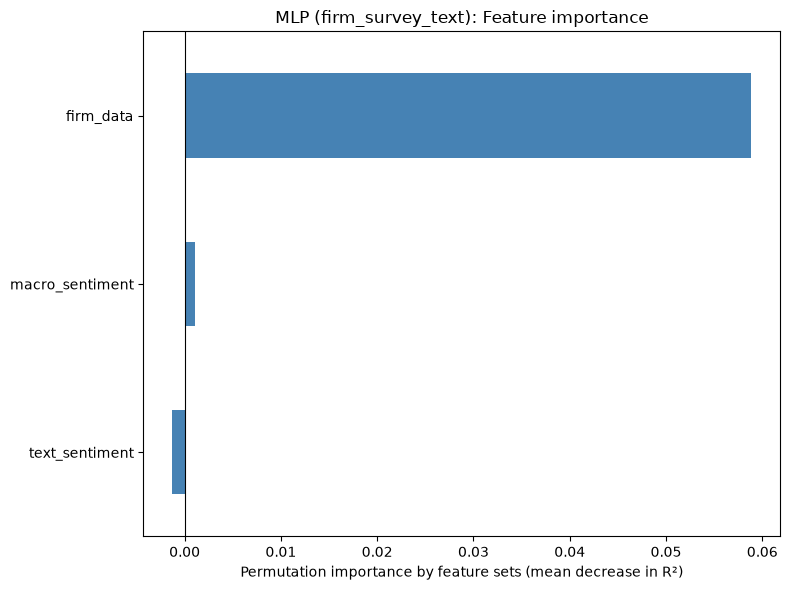

In [33]:
fig, ax = plt.subplots(figsize=(8, 6))
group_importance['importance_mean'].sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Permutation importance by feature sets (mean decrease in R²)")
ax.set_title("MLP (firm_survey_text): Feature importance")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

In [34]:
# Permuation importance by features
from sklearn.inspection import permutation_importance

result = permutation_importance(
    final_models["firm_survey_text"], test_df[FEATURE_SETS["firm_survey_text"]], test_df[TARGET],
    n_repeats=10, random_state=42, scoring='r2'
)
importances = pd.Series(result.importances_mean, index=test_df[FEATURE_SETS["firm_survey_text"]].columns).sort_values(ascending=False)

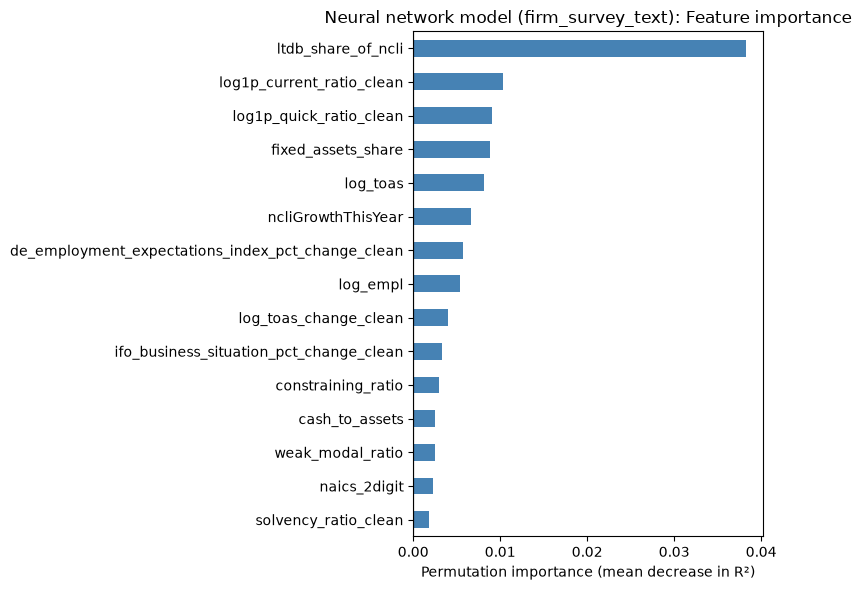

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(15).sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Permutation importance (mean decrease in R²)")
ax.set_title("Neural network model (firm_survey_text): Feature importance")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

In our case, tree-bases model perform better than the neural network, because:
- Many features have missing value and inf value. Tree can handle this issue better by just splitting. Neural network requires complete, imputed inputs. Any imputation method (using mean/median/most frequent value) injects assumptions that NN can easily overfit.
- ncliGrowthNextYear and ratio features are fat-tailed. Trees split on order (rank), so a value being 10x vs 1000x too large doesn't matter, the split threshold is the same. MLPs optimize on raw (or standardized) magnitudes via gradient descent, so extreme values distort loss surfaces and gradients unless you clip/winsorize religiously (which you're already planning).

How outliers affect the MLP

- Gradients scale with raw input values. Extreme observations (e.g., a firm with unusually large toas or extreme ncliGrowthNextYear) produce disproportionately large gradients, so those few examples dominate weight updates instead of the model learning from the "typical" pattern across the bulk of firms.

- Net effect: the MLP's fit gets distorted toward accommodating rare extreme cases, which likely explains why it generalizes poorly to a genuinely different regime (2020 COVID shock) = good CV performance, poor test R²_oos.
- Trees don't have this problem because splits depend only on value ordering, not magnitude - an outlier just falls on one side of a threshold, no leverage effect.



Have to check

Rotation invariance / irrelevant features - The Grinsztajn et al. (2022) paper "Why do tree-based models still outperform deep learning on tabular data" is the canonical reference here: it shows NNs are hurt specifically by (a) uninformative features and (b) non-rotationally-invariant data - both apply to a wide firm-panel dataset with many financial ratios where feature scales and relevance vary a lot. 